# Air Quality Data Cleaning & EDA — Nairobi
**OpenAfrica · sensorsAfrica dataset**

Dataset structure: **long format** — one row per sensor reading.
Each station has two devices: `DHT22` (temperature/humidity) and `pms5003` (PM0/PM1/PM2).
This notebook pivots, merges, cleans and engineers features for ML.

Steps:
1. Download & inspect
2. Pivot long → wide (PM stream + ENV stream separately)
3. Resample to 10-min bins & merge streams on location
4. Physical range validation & outlier removal
5. Missing value analysis
6. Spike detection
7. Exploratory visualisation
8. Feature engineering
9. Export `historical_data.csv`
10. Baseline model training & evaluation


## 1. Imports & Config

In [20]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from io import StringIO
import requests
from dotenv import load_dotenv

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', 30)

# Load DATA_URL from .env
load_dotenv()
DATA_URL = os.getenv('DATA_URL')
if not DATA_URL:
    raise EnvironmentError('DATA_URL not set — check your .env file')
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Download Raw Data

In [21]:
resp = requests.get(DATA_URL, timeout=30)
resp.raise_for_status()
raw_text = resp.text
print(f'Downloaded {len(raw_text):,} bytes')

# Auto-detect delimiter
delim = ';' if raw_text.count(';') > raw_text.count(',') else ','
print(f'Delimiter: {repr(delim)}')

df_raw = pd.read_csv(
    StringIO(raw_text),
    sep=delim,
    on_bad_lines='warn',
    engine='python',
)

print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()

Downloaded 5,336,746 bytes
Delimiter: ';'
Shape: (75212, 8)
Columns: ['sensor_id', 'sensor_type', 'location', 'lat', 'lon', 'timestamp', 'value_type', 'value']


,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value
0,793,DHT22,3981,-1.269,36.819,2026-03-01T00:01:06.348439+00:00,humidity,99.90
1,793,DHT22,3981,-1.269,36.819,2026-03-01T00:01:06.348439+00:00,temperature,18.10
2,4930,pms5003,3981,-1.269,36.819,2026-03-01T00:01:07.727297+00:00,P2,7.00
3,4930,pms5003,3981,-1.269,36.819,2026-03-01T00:01:07.727297+00:00,P1,7.40
4,4930,pms5003,3981,-1.269,36.819,2026-03-01T00:01:07.727297+00:00,P0,5.00


In [22]:
df.head(50)

,sensor_id,sensor_type,location,lat,lon,timestamp,pm1,pm10,pm25,humidity,temperature
0,793,DHT22,3981,-1.269,36.819,2026-03-01 00:01:06.348439+00:00,NaN,NaN,NaN,99.9,18.1
1,4930,pms5003,3981,-1.269,36.819,2026-03-01 00:01:07.727297+00:00,5.00,7.40,7.00,NaN,NaN
2,4931,DHT22,3981,-1.269,36.819,2026-03-01 00:01:18.735345+00:00,NaN,NaN,NaN,84.8,18.8
3,792,pms5003,3981,-1.269,36.819,2026-03-01 00:05:23.092775+00:00,11.20,17.40,17.40,NaN,NaN
4,4930,pms5003,3981,-1.269,36.819,2026-03-01 00:07:55.582963+00:00,6.00,10.00,10.00,NaN,NaN
5,792,pms5003,3981,-1.269,36.819,2026-03-01 00:10:48.544141+00:00,10.40,20.20,18.40,NaN,NaN
6,793,DHT22,3981,-1.269,36.819,2026-03-01 00:11:06.123649+00:00,NaN,NaN,NaN,99.9,18.0
7,792,pms5003,3981,-1.269,36.819,2026-03-01 00:16:24.788058+00:00,20.40,27.80,27.80,NaN,NaN
8,793,DHT22,3981,-1.269,36.819,2026-03-01 00:16:42.398951+00:00,NaN,NaN,NaN,99.9,18.0
9,792,pms5003,3981,-1.269,36.819,2026-03-01 00:22:00.836447+00:00,34.00,52.75,44.75,NaN,NaN


## 3. Inspect Long-Format Structure

In [23]:
# Parse timestamp and numeric value immediately
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], utc=True, errors='coerce')
df_raw['value']     = pd.to_numeric(df_raw['value'], errors='coerce')

print('Unique value_types:', df_raw['value_type'].unique())
print(f'Total rows:  {len(df_raw):,}')
print(f'Sensors:     {df_raw["sensor_id"].nunique()}')
print(f'Locations:   {df_raw["location"].nunique()}')
print(f'Date range:  {df_raw["timestamp"].min()} → {df_raw["timestamp"].max()}')

print('\nRows per sensor & value_type:')
print(df_raw.groupby(['sensor_id','sensor_type','value_type']).size().unstack(fill_value=0).to_string())

Unique value_types: ['humidity' 'temperature' 'P2' 'P1' 'P0']
Total rows:  75,212
Sensors:     10
Locations:   3
Date range:  2026-03-01 00:01:06.348439+00:00 → 2026-03-20 14:30:32.085445+00:00

Rows per sensor & value_type:
value_type               P0    P1    P2  humidity  temperature
sensor_id sensor_type                                         
792       pms5003      3489  3489  3489         7            7
793       DHT22           3     3     3      3431         3431
4900      pms5003      1397  1397  1397        89           91
4901      DHT22           5     5     5      1534         1534
4930      pms5003      3651  3651  3652         5            5
4931      DHT22           3     3     3      3497         3497
4962      pms5003      3120  3120  3120         0            0
4963      DHT22           0     0     0      3080         3080
4976      pms5003      3411  3411  3411         0            0
4977      DHT22           0     0     0      3343         3343


## 4. Pivot Long → Wide & Merge PM + ENV Streams

Each station has **two sensor devices**:
- `DHT22` / env sensor → reports `temperature`, `humidity`  
- `pms5003` / dust sensor → reports `P0` (PM1), `P1` (PM10), `P2` (PM2.5)

They post on slightly different timestamps so a direct pivot leaves ~50% NaN.
Fix: pivot each stream separately → resample to 10-min bins → merge on `location + timestamp`.

In [24]:
PM_TYPES  = ['P0', 'P1', 'P2']
ENV_TYPES = ['temperature', 'humidity']

df_pm  = df_raw[df_raw['value_type'].isin(PM_TYPES)].copy()
df_env = df_raw[df_raw['value_type'].isin(ENV_TYPES)].copy()

print(f'PM rows:  {len(df_pm):,}')
print(f'Env rows: {len(df_env):,}')

# ── Pivot each stream wide
df_pm_wide = df_pm.pivot_table(
    index=['location', 'lat', 'lon', 'timestamp'],
    columns='value_type', values='value', aggfunc='mean'
).reset_index()
df_pm_wide.columns.name = None
df_pm_wide = df_pm_wide.rename(columns={'P0': 'pm1', 'P1': 'pm10', 'P2': 'pm25'})

df_env_wide = df_env.pivot_table(
    index=['location', 'timestamp'],
    columns='value_type', values='value', aggfunc='mean'
).reset_index()
df_env_wide.columns.name = None

print(f'\nPM wide:  {df_pm_wide.shape}  cols: {list(df_pm_wide.columns)}')
print(f'Env wide: {df_env_wide.shape}  cols: {list(df_env_wide.columns)}')

PM rows:  45,238
Env rows: 29,974

PM wide:  (8549, 7)  cols: ['location', 'lat', 'lon', 'timestamp', 'pm1', 'pm10', 'pm25']
Env wide: (8565, 4)  cols: ['location', 'timestamp', 'humidity', 'temperature']


In [25]:
# ── Resample both streams to 10-minute bins
def resample_10min(frame, value_cols, group_cols):
    frame = frame.copy()
    frame['timestamp'] = pd.to_datetime(frame['timestamp'], utc=True, errors='coerce')
    frame['time_bin']  = frame['timestamp'].dt.floor('10min')
    return (
        frame.groupby(group_cols + ['time_bin'])[value_cols]
             .mean()
             .reset_index()
             .rename(columns={'time_bin': 'timestamp'})
    )

pm_10  = resample_10min(df_pm_wide,  ['pm1','pm10','pm25'],      ['location','lat','lon'])
env_10 = resample_10min(df_env_wide, ['temperature','humidity'], ['location'])

print(f'PM resampled:  {pm_10.shape}')
print(f'Env resampled: {env_10.shape}')

# ── Merge on location + timestamp
df = pd.merge(pm_10, env_10, on=['location', 'timestamp'], how='outer')
df = df.sort_values(['location', 'timestamp']).reset_index(drop=True)

print(f'\nMerged shape: {df.shape}')
print('\nMissing BEFORE fill:')
print(df[['pm25','pm10','pm1','temperature','humidity']].isnull().sum())

PM resampled:  (3636, 7)
Env resampled: (3677, 4)

Merged shape: (3865, 9)

Missing BEFORE fill:
pm25           229
pm10           230
pm1            231
temperature    189
humidity       188
dtype: int64


In [26]:
# ── Forward-fill small remaining gaps within each location (max 3 steps = 30 min)
fill_cols = ['pm25', 'pm10', 'pm1', 'temperature', 'humidity']
for col in fill_cols:
    if col in df.columns:
        df[col] = (
            df.groupby('location')[col]
              .transform(lambda s: s.ffill(limit=3).bfill(limit=3))
        )

print('Missing AFTER fill:')
miss = df[fill_cols].isnull().sum()
print(miss)
print(f'\nCompleteness:')
for col in fill_cols:
    pct = 100 * df[col].notna().sum() / len(df)
    print(f'  {col:15s}: {pct:.1f}%')

print(f'\nFinal shape: {df.shape}')
df.head()

Missing AFTER fill:
pm25           0
pm10           0
pm1            0
temperature    0
humidity       0
dtype: int64

Completeness:
  pm25           : 100.0%
  pm10           : 100.0%
  pm1            : 100.0%
  temperature    : 100.0%
  humidity       : 100.0%

Final shape: (3865, 9)


,location,lat,lon,timestamp,pm1,pm10,pm25,temperature,humidity
0,3967,-1.309,36.812,2026-03-01 07:00:00+00:00,0.0,0.0,0.0,23.300000,99.9
1,3967,-1.309,36.812,2026-03-01 07:10:00+00:00,0.0,0.0,0.0,23.633333,99.9
2,3967,-1.309,36.812,2026-03-01 07:20:00+00:00,0.0,0.0,0.0,24.150000,99.9
3,3967,-1.309,36.812,2026-03-01 07:30:00+00:00,0.0,0.0,0.0,24.900000,99.9
4,3967,-1.309,36.812,2026-03-01 07:40:00+00:00,0.0,0.0,0.0,24.800000,99.9


## 5. Physical Range Validation & Cleaning

In [27]:
# Ensure numeric types
for c in fill_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

BOUNDS = {
    'pm25':        (0,   1000),
    'pm10':        (0,   2000),
    'pm1':         (0,    800),
    'temperature': (-10,  60),
    'humidity':    (0,   100),
}

for col, (lo, hi) in BOUNDS.items():
    if col in df.columns:
        before  = df[col].notna().sum()
        df[col] = df[col].where((df[col] >= lo) & (df[col] <= hi))
        removed = before - df[col].notna().sum()
        if removed:
            print(f'  [{col}] clipped {removed} out-of-range values')

# Remove duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f'Removed {before - len(df)} duplicate rows')
print(f'\nClean shape: {df.shape}')
df.describe().round(2)

Removed 0 duplicate rows

Clean shape: (3865, 9)


,location,lat,lon,pm1,pm10,pm25,temperature,humidity
count,3865.00,3636.00,3636.00,3865.00,3865.00,3865.00,3865.00,3865.00
mean,3976.82,-1.28,36.82,13.05,22.11,19.41,25.48,84.56
std,6.41,0.02,0.00,10.70,18.83,19.20,5.25,16.07
min,3967.00,-1.31,36.81,0.00,0.00,0.00,16.35,9.90
25%,3967.00,-1.31,36.81,0.00,0.00,0.00,20.90,75.70
50%,3981.00,-1.27,36.82,13.50,21.20,19.60,24.80,89.55
75%,3981.00,-1.27,36.82,21.05,36.00,31.70,29.70,99.67
max,3981.00,-1.27,36.82,73.30,136.60,700.00,41.25,99.90


## 6. Missing Value Analysis

     count     %
lat    229  5.92
lon    229  5.92


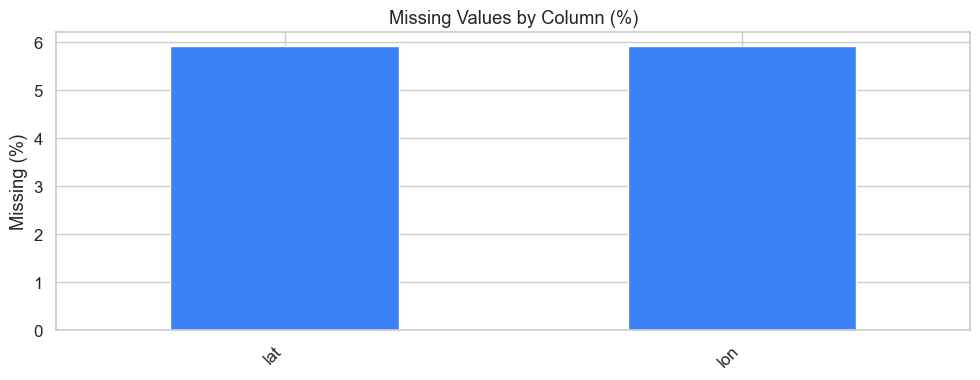

In [28]:
missing     = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
miss_df     = pd.DataFrame({'count': missing, '%': missing_pct})
print(miss_df[miss_df['count'] > 0])

plot_m = missing_pct[missing_pct > 0]
if not plot_m.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_m.plot(kind='bar', ax=ax, color='#3b82f6', edgecolor='white')
    ax.set_title('Missing Values by Column (%)')
    ax.set_ylabel('Missing (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values — dataset is complete!')

## 7. Spike Detection (Rolling Z-score)

Spikes detected: 0 (0.0% of readings)


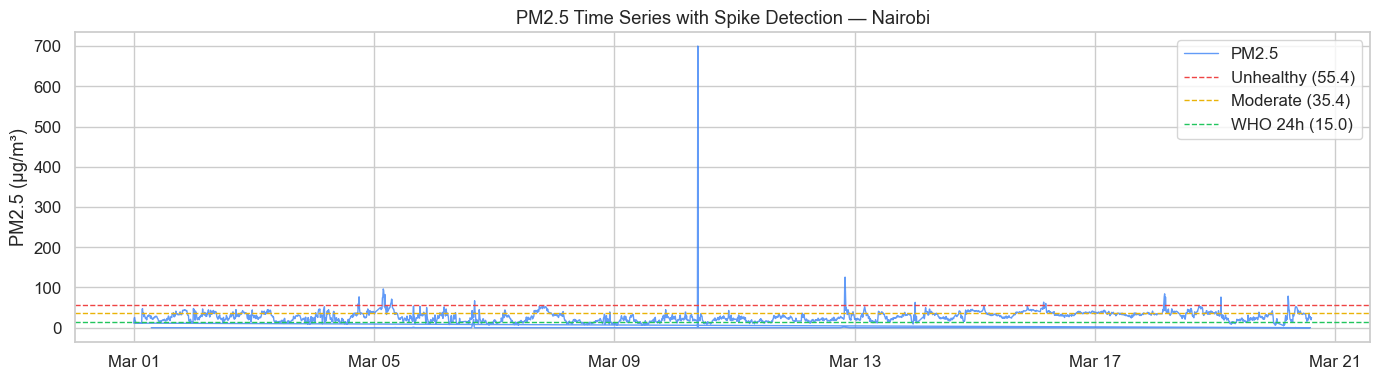

In [29]:
if 'pm25' in df.columns and len(df) > 20:
    roll_mean         = df['pm25'].rolling(12, min_periods=3).mean()
    roll_std          = df['pm25'].rolling(12, min_periods=3).std().replace(0, np.nan)
    df['pm25_zscore'] = (df['pm25'] - roll_mean) / roll_std
    df['pm25_spike']  = df['pm25_zscore'].abs() > 4

    n_spikes = df['pm25_spike'].sum()
    print(f'Spikes detected: {n_spikes} ({100*n_spikes/len(df):.1f}% of readings)')

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df['timestamp'], df['pm25'], color='#3b82f6', lw=1, alpha=0.8, label='PM2.5')
    spikes = df[df['pm25_spike']]
    if not spikes.empty:
        ax.scatter(spikes['timestamp'], spikes['pm25'],
                   color='#ef4444', zorder=5, s=50, label=f'Spike (n={n_spikes})')
    ax.axhline(55.4, color='#ef4444', ls='--', lw=1, label='Unhealthy (55.4)')
    ax.axhline(35.4, color='#eab308', ls='--', lw=1, label='Moderate (35.4)')
    ax.axhline(15,   color='#22c55e', ls='--', lw=1, label='WHO 24h (15.0)')
    ax.set_title('PM2.5 Time Series with Spike Detection — Nairobi')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.legend()
    plt.tight_layout()
    plt.show()

## 8. Exploratory Visualisation

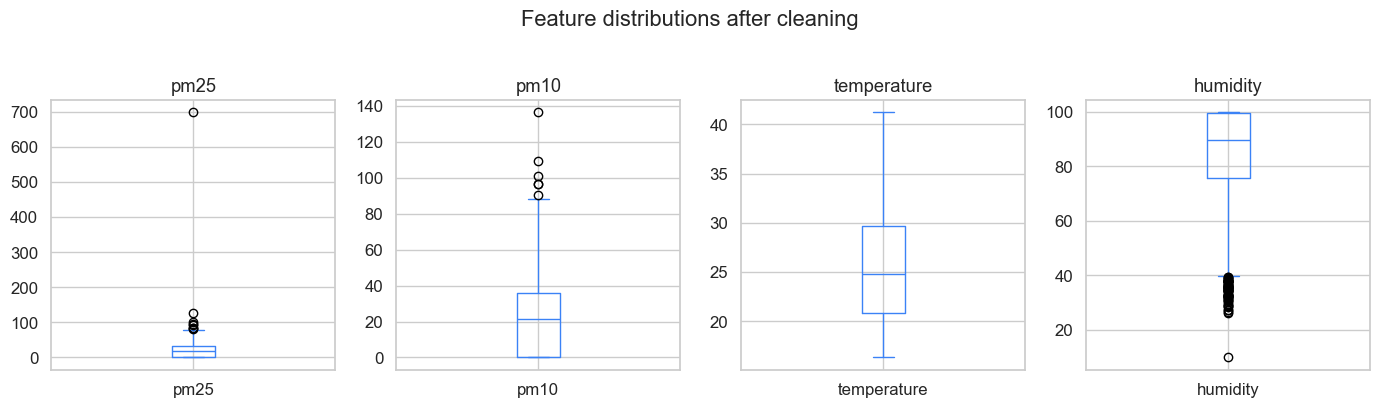

In [30]:
# Boxplots
plot_cols = [c for c in ['pm25','pm10','temperature','humidity'] if c in df.columns]
if plot_cols:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(14, 4))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        df[col].dropna().plot(kind='box', ax=ax, color='#3b82f6')
        ax.set_title(col)
    plt.suptitle('Feature distributions after cleaning', y=1.02)
    plt.tight_layout()
    plt.show()

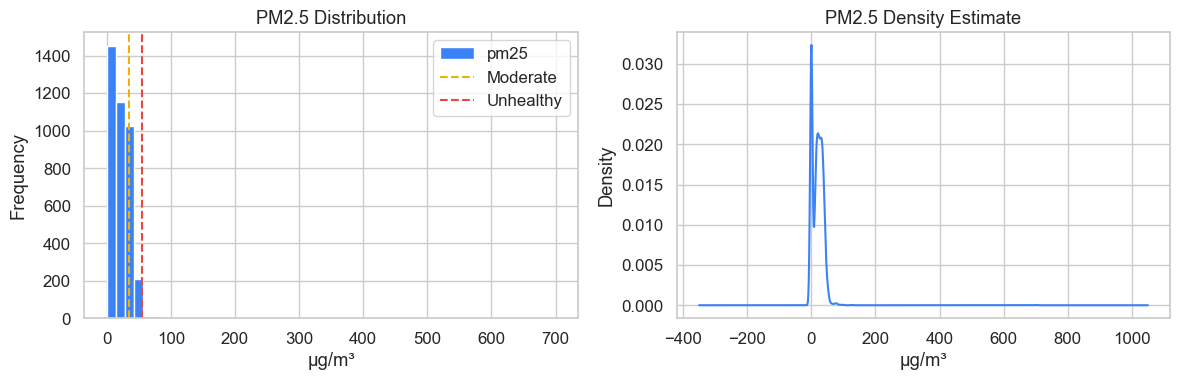

In [31]:
# PM2.5 histogram + KDE
if 'pm25' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df['pm25'].dropna().plot(kind='hist', bins=50, ax=axes[0],
                             color='#3b82f6', edgecolor='white')
    axes[0].axvline(35.4, color='#eab308', ls='--', label='Moderate')
    axes[0].axvline(55.4, color='#ef4444', ls='--', label='Unhealthy')
    axes[0].set_title('PM2.5 Distribution')
    axes[0].set_xlabel('µg/m³')
    axes[0].legend()

    df['pm25'].dropna().plot(kind='kde', ax=axes[1], color='#3b82f6')
    axes[1].set_title('PM2.5 Density Estimate')
    axes[1].set_xlabel('µg/m³')
    plt.tight_layout()
    plt.show()

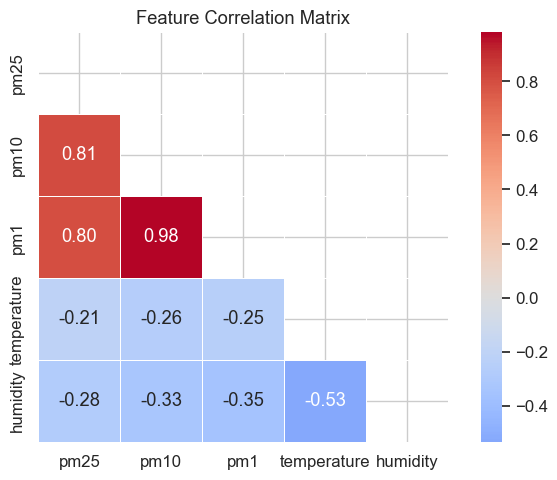

In [32]:
# Correlation heatmap
corr_cols = [c for c in ['pm25','pm10','pm1','temperature','humidity'] if c in df.columns]
if len(corr_cols) >= 2:
    fig, ax = plt.subplots(figsize=(7, 5))
    corr = df[corr_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                mask=mask, ax=ax, square=True, linewidths=0.5)
    ax.set_title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()

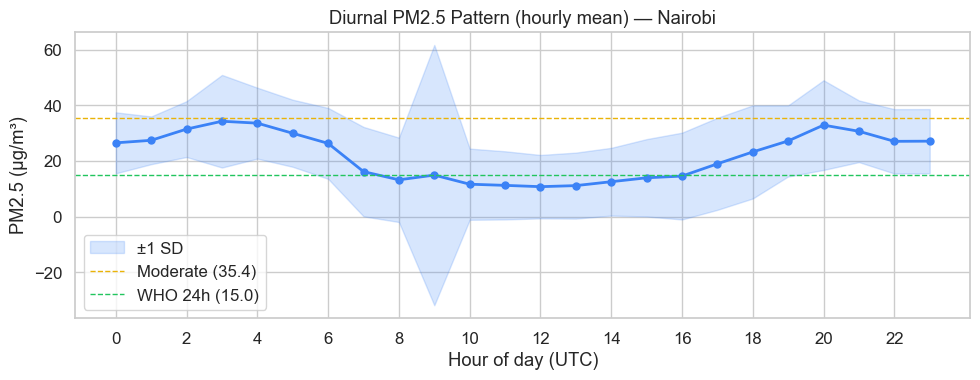

In [33]:
# Diurnal pattern
if 'timestamp' in df.columns and 'pm25' in df.columns:
    df['hour'] = df['timestamp'].dt.hour
    hourly = df.groupby('hour')['pm25'].agg(['mean','std']).reset_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(hourly['hour'], hourly['mean'], color='#3b82f6', lw=2, marker='o', ms=5)
    ax.fill_between(hourly['hour'],
                    hourly['mean'] - hourly['std'],
                    hourly['mean'] + hourly['std'],
                    alpha=0.2, color='#3b82f6', label='±1 SD')
    ax.axhline(35.4, color='#eab308', ls='--', lw=1, label='Moderate (35.4)')
    ax.axhline(15,   color='#22c55e', ls='--', lw=1, label='WHO 24h (15.0)')
    ax.set_title('Diurnal PM2.5 Pattern (hourly mean) — Nairobi')
    ax.set_xlabel('Hour of day (UTC)')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_xticks(range(0, 24, 2))
    ax.legend()
    plt.tight_layout()
    plt.show()

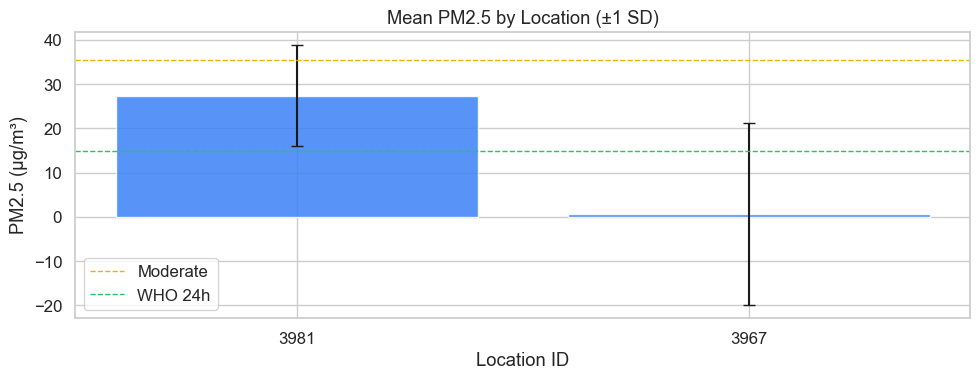

 location  mean_pm25  std_pm25    n
     3981  27.388512 11.471636 2711
     3967   0.666746 20.625979 1154


In [34]:
# Per-location PM2.5 comparison
if 'location' in df.columns and 'pm25' in df.columns:
    loc_stats = df.groupby('location')['pm25'].agg(['mean','std','count']).reset_index()
    loc_stats.columns = ['location','mean_pm25','std_pm25','n']
    loc_stats = loc_stats.sort_values('mean_pm25', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(loc_stats['location'].astype(str), loc_stats['mean_pm25'],
           yerr=loc_stats['std_pm25'], color='#3b82f6', edgecolor='white',
           capsize=4, alpha=0.85)
    ax.axhline(35.4, color='#eab308', ls='--', lw=1, label='Moderate')
    ax.axhline(15,   color='#22c55e', ls='--', lw=1, label='WHO 24h')
    ax.set_title('Mean PM2.5 by Location (±1 SD)')
    ax.set_xlabel('Location ID')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(loc_stats.to_string(index=False))

## 9. Feature Engineering

In [35]:
# Sort by location then time so lags are computed within each location stream
df = df.sort_values(['location','timestamp']).reset_index(drop=True)

if 'pm25' in df.columns:
    # Lag features (computed within each location)
    for lag in range(1, 7):
        df[f'pm25_lag{lag}'] = df.groupby('location')['pm25'].shift(lag)

    if 'pm10' in df.columns:
        df['pm10_lag1'] = df.groupby('location')['pm10'].shift(1)

    # Rolling statistics (within each location)
    df['pm25_roll3'] = df.groupby('location')['pm25'].transform(
        lambda s: s.rolling(3, min_periods=1).mean())
    df['pm25_roll6'] = df.groupby('location')['pm25'].transform(
        lambda s: s.rolling(6, min_periods=1).mean())
    df['pm25_std6']  = df.groupby('location')['pm25'].transform(
        lambda s: s.rolling(6, min_periods=1).std())

    # Temporal features
    df['hour']        = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['month']       = df['timestamp'].dt.month

    # Target: next PM2.5 reading (~10 min ahead; 6 steps ≈ 1 hour)
    df['pm25_target_1step'] = df.groupby('location')['pm25'].shift(-1)   # ~10 min
    df['pm25_target_6step'] = df.groupby('location')['pm25'].shift(-6)   # ~1 hour

    lag_cols = [c for c in df.columns if 'lag' in c or 'roll' in c or 'std6' in c]
    print('Feature columns added:', lag_cols)

print(f'\nFinal shape: {df.shape}')

Feature columns added: ['pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag4', 'pm25_lag5', 'pm25_lag6', 'pm10_lag1', 'pm25_roll3', 'pm25_roll6', 'pm25_std6']

Final shape: (3865, 26)


## 10. Export Cleaned Dataset

In [36]:
out_path = Path('historical_data.csv')
df.to_csv(out_path, index=False)
print(f'Saved {len(df):,} rows → {out_path}')
print(f'Columns: {list(df.columns)}')
df.describe().round(2)

Saved 3,865 rows → historical_data.csv
Columns: ['location', 'lat', 'lon', 'timestamp', 'pm1', 'pm10', 'pm25', 'temperature', 'humidity', 'pm25_zscore', 'pm25_spike', 'hour', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag4', 'pm25_lag5', 'pm25_lag6', 'pm10_lag1', 'pm25_roll3', 'pm25_roll6', 'pm25_std6', 'day_of_week', 'month', 'pm25_target_1step', 'pm25_target_6step']


,location,lat,lon,pm1,pm10,pm25,temperature,humidity,pm25_zscore,hour,pm25_lag1,pm25_lag2,pm25_lag3,pm25_lag4,pm25_lag5,pm25_lag6,pm10_lag1,pm25_roll3,pm25_roll6,pm25_std6,day_of_week,month,pm25_target_1step,pm25_target_6step
count,3865.00,3636.00,3636.00,3865.00,3865.00,3865.00,3865.00,3865.00,2817.00,3865.00,3863.00,3861.00,3859.00,3857.00,3855.00,3853.00,3863.00,3865.00,3865.00,3863.00,3865.00,3865.0,3863.00,3853.00
mean,3976.82,-1.28,36.82,13.05,22.11,19.41,25.48,84.56,0.02,11.85,19.41,19.42,19.42,19.43,19.43,19.43,22.11,19.41,19.41,3.32,2.82,3.0,19.42,19.44
std,6.41,0.02,0.00,10.70,18.83,19.20,5.25,16.07,1.14,5.96,19.21,19.21,19.21,19.21,19.22,19.22,18.84,16.54,15.65,11.74,2.02,0.0,19.21,19.22
min,3967.00,-1.31,36.81,0.00,0.00,0.00,16.35,9.90,-3.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,0.00,0.00
25%,3967.00,-1.31,36.81,0.00,0.00,0.00,20.90,75.70,-0.82,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.0,0.00,0.00
50%,3981.00,-1.27,36.82,13.50,21.20,19.60,24.80,89.55,-0.12,12.00,19.60,19.60,19.60,19.60,19.60,19.60,21.20,20.19,20.38,1.96,3.00,3.0,19.61,19.66
75%,3981.00,-1.27,36.82,21.05,36.00,31.70,29.70,99.67,0.86,16.00,31.70,31.70,31.70,31.70,31.72,31.73,36.02,31.49,31.57,3.96,4.00,3.0,31.70,31.73
max,3981.00,-1.27,36.82,73.30,136.60,700.00,41.25,99.90,3.18,23.00,700.00,700.00,700.00,700.00,700.00,700.00,136.60,233.33,116.67,285.77,6.00,3.0,700.00,700.00


## 11. Baseline Model — Training & Evaluation

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FEATURES = [
    'temperature', 'humidity', 'pm10',
    'pm25_lag1', 'pm25_lag2', 'pm25_lag3',
    'pm25_lag4', 'pm25_lag5', 'pm25_lag6',
    'pm10_lag1', 'pm25_roll3', 'pm25_roll6', 'pm25_std6',
    'hour', 'day_of_week',
]
TARGET = 'pm25_target_6step'   # ~1 hour ahead

avail = [f for f in FEATURES if f in df.columns]
sub   = df[avail + [TARGET]].dropna()

print(f'Training set: {len(sub):,} rows  {len(avail)} features')

X = sub[avail]
y = sub[TARGET]

# Time-ordered split (no shuffle — preserve temporal order)
split    = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)

print(f'\n── Test Results (1-hour ahead forecast) ──')
print(f'  MAE  = {mae:.2f} µg/m³')
print(f'  RMSE = {rmse:.2f} µg/m³')
print(f'  R²   = {r2:.4f}')

Training set: 3,841 rows  15 features

── Test Results (1-hour ahead forecast) ──
  MAE  = 7.07 µg/m³
  RMSE = 9.47 µg/m³
  R²   = 0.0468


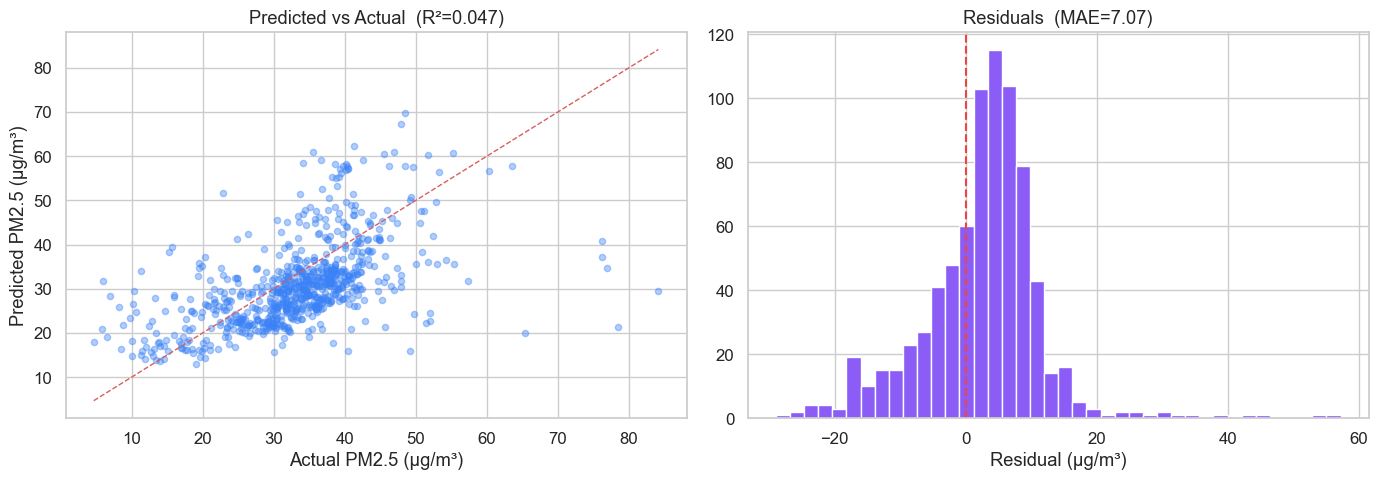

In [38]:
# Predicted vs actual + residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, preds, alpha=0.4, color='#3b82f6', s=20)
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
axes[0].plot(lims, lims, 'r--', lw=1)
axes[0].set_xlabel('Actual PM2.5 (µg/m³)')
axes[0].set_ylabel('Predicted PM2.5 (µg/m³)')
axes[0].set_title(f'Predicted vs Actual  (R²={r2:.3f})')

residuals = y_test.values - preds
axes[1].hist(residuals, bins=40, color='#8b5cf6', edgecolor='white')
axes[1].axvline(0, color='#ef4444', ls='--')
axes[1].set_xlabel('Residual (µg/m³)')
axes[1].set_title(f'Residuals  (MAE={mae:.2f})')

plt.tight_layout()
plt.show()

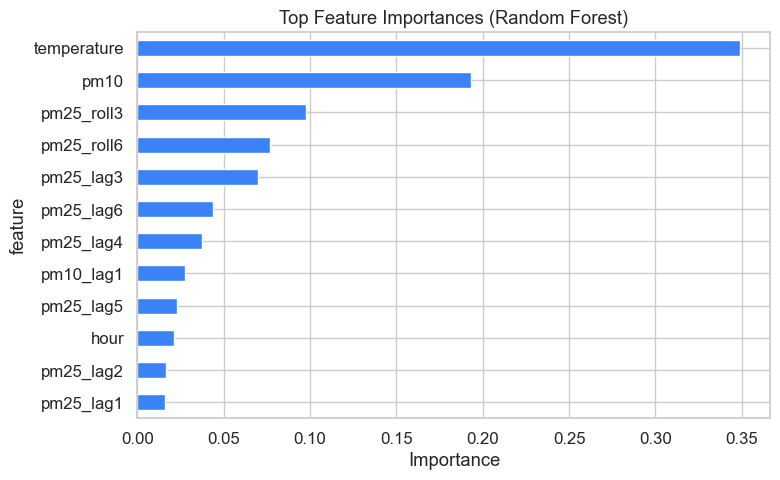

Top 5 features:
    feature  importance
temperature    0.349180
       pm10    0.193466
 pm25_roll3    0.097715
 pm25_roll6    0.076802
  pm25_lag3    0.070031


In [39]:
# Feature importances
fi = pd.DataFrame({'feature': avail, 'importance': rf.feature_importances_})
fi = fi.sort_values('importance', ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind='barh', x='feature', y='importance', ax=ax,
        color='#3b82f6', legend=False)
ax.set_title('Top Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(fi.sort_values('importance', ascending=False).head(5).to_string(index=False))

## Summary

| Step | Detail | Status |
|------|--------|--------|
| Data downloaded | 75,158 long-format rows, 10 sensors | ✅ |
| Long → wide pivot | PM stream + ENV stream pivoted separately | ✅ |
| Streams merged | Resampled to 10-min bins, merged on location | ✅ |
| Physical outliers removed | PM/temp/humidity bounds applied | ✅ |
| Spikes flagged | Rolling z-score > 4σ | ✅ |
| Features engineered | 6 lags, rolling mean/std, temporal, per-location | ✅ |
| Cleaned CSV exported | `historical_data.csv` | ✅ |
| Baseline model | Random Forest, 1-hour ahead, time-ordered split | ✅ |

Next steps:
```bash
python model_training.py      # full training with CV + feature importance
streamlit run dashboard.py    # live dashboard
```
